# Entrenamiento y exportación de modelos (Proyecto B - Churn)

Este notebook entrena los **dos modelos** del Proyecto B:
- **Modelo 1**: Clasificación binaria (Churn Yes/No) -> `model_churn_class.keras`
- **Modelo 2**: Regresión / scoring de riesgo (0.0 a 1.0) -> `model_churn_reg.keras`

También se guarda el `StandardScaler` entrenado (`scaler.pkl`) y la lista de columnas (`feature_columns.pkl`), necesarios para que la API pueda transformar correctamente los datos nuevos antes de predecir.

**Ejecutar en un entorno con TensorFlow + imbalanced-learn instalados (Colab recomendado).**

In [1]:
!pip install imbalanced-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam as KerasAdam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

## Cargar datos limpios (`customer_clean.csv`)

In [3]:
df = pd.read_csv("customer_clean.csv")
X = df.drop('Churn', axis=1)
y = df['Churn']

feature_columns = X.columns.tolist()
print("N° de features:", len(feature_columns))
print(feature_columns)

N° de features: 26
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No']


## Balanceo con SMOTE y escalado

Importante: el `scaler` se ajusta (fit) **después** del SMOTE, igual que en los notebooks originales, y se guarda para reutilizarlo en la API.

In [4]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

X_train, X_test, y_train, y_test = train_test_split(
    X_res_scaled, y_res, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (8260, 26) X_test: (2066, 26)


## Modelo 1 - Clasificación Binaria (Churn Yes/No)

In [5]:
model_class = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_class.compile(
    optimizer=KerasAdam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_class = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
reduce_lr_class = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=7, min_lr=1e-6)

history_class = model_class.fit(
    X_train, y_train, epochs=400, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_class, reduce_lr_class], verbose=1
)

Epoch 1/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7662 - loss: 0.4910 - val_accuracy: 0.7938 - val_loss: 0.4279 - learning_rate: 3.0000e-04
Epoch 2/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8131 - loss: 0.4095 - val_accuracy: 0.8306 - val_loss: 0.3765 - learning_rate: 3.0000e-04
Epoch 3/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8199 - loss: 0.3928 - val_accuracy: 0.8291 - val_loss: 0.3657 - learning_rate: 3.0000e-04
Epoch 4/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8259 - loss: 0.3737 - val_accuracy: 0.8354 - val_loss: 0.3613 - learning_rate: 3.0000e-04
Epoch 5/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8297 - loss: 0.3636 - val_accuracy: 0.8330 - val_loss: 0.3569 - learning_rate: 3.0000e-04
Epoch 6/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8309 - loss: 0.3604 - val_accuracy: 0.8398 - val_loss: 0.3539 - learning_rate: 3.0000e-04
Epoch 7/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

loss_class, acc_class = model_class.evaluate(X_test, y_test, verbose=0)
print(f"Modelo Clasificación - Accuracy: {acc_class:.4f}")

y_pred_class = (model_class.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_class, target_names=['No Churn', 'Churn']))
print(confusion_matrix(y_test, y_pred_class))

Modelo Clasificación - Accuracy: 0.8475
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1037
       Churn       0.85      0.84      0.85      1029

    accuracy                           0.85      2066
   macro avg       0.85      0.85      0.85      2066
weighted avg       0.85      0.85      0.85      2066

[[885 152]
 [163 866]]


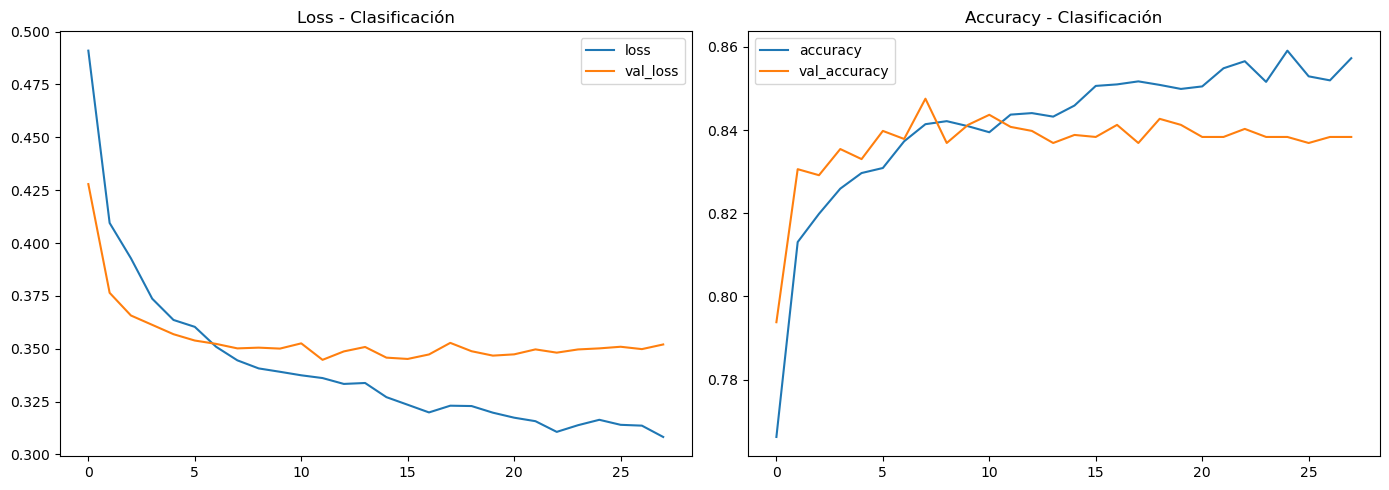

In [7]:
model_loss = pd.DataFrame(history_class.history)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
model_loss[['loss','val_loss']].plot(ax=axes[0], title='Loss - Clasificación')
model_loss[['accuracy','val_accuracy']].plot(ax=axes[1], title='Accuracy - Clasificación')
plt.tight_layout()
plt.show()

## Modelo 2 - Regresión (Probabilidad de Churn 0.0 - 1.0)

In [8]:
model_reg = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_reg.compile(
    optimizer=KerasAdam(learning_rate=0.0005),
    loss='huber',
    metrics=['mae']
)

early_stop_reg = EarlyStopping(monitor='val_mae', patience=20, restore_best_weights=True)
reduce_lr_reg = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=7, min_lr=1e-6)

history_reg = model_reg.fit(
    X_train, y_train, epochs=300, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_reg, reduce_lr_reg], verbose=1
)

Epoch 1/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0741 - mae: 0.2846 - val_loss: 0.0726 - val_mae: 0.2719 - learning_rate: 5.0000e-04
Epoch 2/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0632 - mae: 0.2423 - val_loss: 0.0618 - val_mae: 0.2231 - learning_rate: 5.0000e-04
Epoch 3/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0602 - mae: 0.2314 - val_loss: 0.0581 - val_mae: 0.2135 - learning_rate: 5.0000e-04
Epoch 4/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0582 - mae: 0.2248 - val_loss: 0.0569 - val_mae: 0.2220 - learning_rate: 5.0000e-04
Epoch 5/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0571 - mae: 0.2224 - val_loss: 0.0572 - val_mae: 0.2108 - learning_rate: 5.0000e-04
Epoch 6/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0570 - mae: 0.2228 - val_loss: 0.0571 - val_mae: 0.2135 - learning_rate: 5.0000e-04
Epoch 7/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0551 - mae: 0.2148 - val_loss: 0.0566 - val_mae: 0.2063

Modelo Regresión - MAE: 0.1959


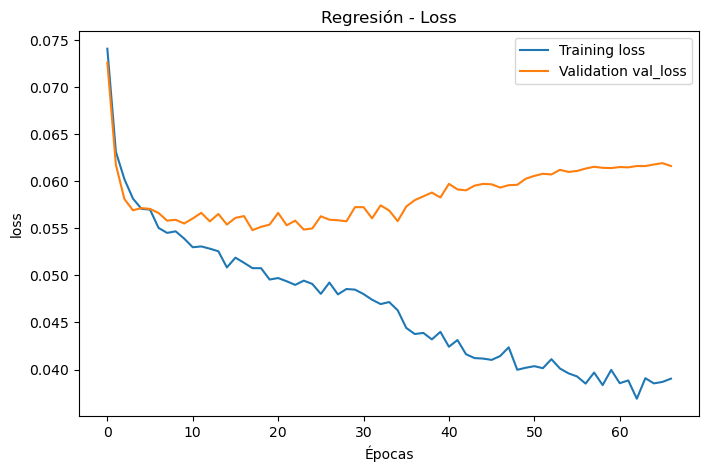

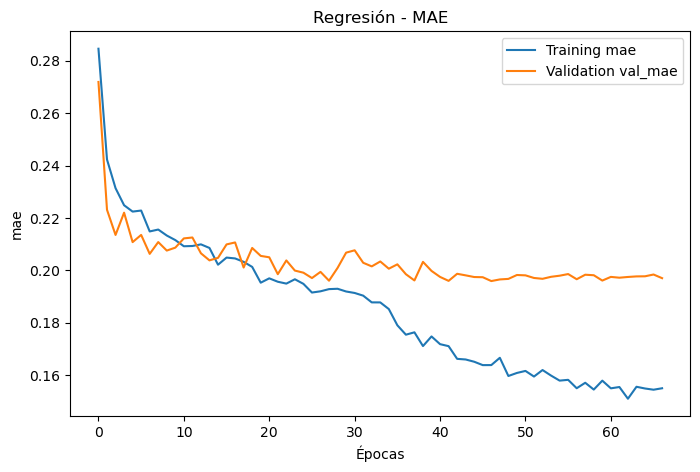

In [9]:
loss_reg, mae_reg = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"Modelo Regresión - MAE: {mae_reg:.4f}")

def plot_history(history, metric, val_metric, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[val_metric], label=f'Validation {val_metric}')
    plt.title(title)
    plt.xlabel("Épocas")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

plot_history(history_reg, 'loss', 'val_loss', "Regresión - Loss")
plot_history(history_reg, 'mae', 'val_mae', "Regresión - MAE")

## Segmentación por nivel de riesgo (sobre el set de prueba)

In [10]:
y_pred_reg = model_reg.predict(X_test).flatten()

def segmentar_riesgo(prob):
    if prob < 0.33:
        return "Bajo"
    elif prob < 0.66:
        return "Medio"
    else:
        return "Alto"

segmentos = [segmentar_riesgo(p) for p in y_pred_reg]
import collections
print("Distribución por riesgo:", collections.Counter(segmentos))

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Distribución por riesgo: Counter({'Bajo': 913, 'Alto': 885, 'Medio': 268})


## Guardar modelos (.keras), scaler y columnas

Estos 4 archivos son los que se copian a la carpeta `models/` y se usan en la API.

In [11]:
model_class.save("model_churn_class.keras")
model_reg.save("model_churn_reg.keras")

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Modelos, scaler y columnas guardados correctamente.")

Modelos, scaler y columnas guardados correctamente.
